In [1]:
import pandas as pd
df_1 = pd.read_csv('du_lieu_thoi_tiet.csv')
df_2 = pd.read_csv('du_lieu_diem.csv')
df_3 = pd.read_csv('du_lieu_tranh.csv')

# Bayes

In [ ]:
import numpy as np

def calc_prior(df, target_col):
    """Tính xác suất tiên nghiệm P(class) cho từng lớp."""
    class_counts = df[target_col].value_counts()
    total = len(df)
    priors = {cls: count / total for cls, count in class_counts.items()}
    return priors

def calc_likelihood(df, feature, value, target_col, target_value):
    """Tính xác suất có điều kiện P(feature=value | class=target_value)."""
    subset = df[df[target_col] == target_value]
    count = np.sum(subset[feature] == value)
    total = len(subset)
    if total == 0:
        return 0
    return count / total

def predict_bayes(df, sample, target_col):
    """Dự đoán lớp cho một mẫu bằng Bayes (không làm trơn Laplace)."""
    priors = calc_prior(df, target_col)
    classes = priors.keys()
    posteriors = {}
    for cls in classes:
        prob = priors[cls]
        for feature, value in sample.items():
            prob *= calc_likelihood(df, feature, value, target_col, cls)
        posteriors[cls] = prob
    # Chọn lớp có xác suất hậu nghiệm lớn nhất
    return max(posteriors, key=posteriors.get), posteriors

sample = {'Outlook': 'Rainy', 'Temp': 'Hot', 'Humidity': 'High', 'Windy': False}
predicted_class, posteriors = predict_bayes(df_1, sample, 'Play')
print("Dự đoán lớp:", predicted_class)
print("Xác suất hậu nghiệm:", posteriors)

Dự đoán lớp: No
Xác suất hậu nghiệm: {'Yes': 0.010582010582010581, 'No': 0.027428571428571438}


# Bayes có làm trơn Laplace

In [6]:
def calc_likelihood_laplace(df, feature, value, target_col, target_value):
    """Tính xác suất có điều kiện P(feature=value | class=target_value) với làm trơn Laplace."""
    subset = df[df[target_col] == target_value]
    count = np.sum(subset[feature] == value)
    total = len(subset)
    # Số lượng giá trị khác nhau của feature (số lượng nhãn)
    n_values = df[feature].nunique()
    return (count + 1) / (total + n_values)

def predict_bayes_laplace(df, sample, target_col):
    """Dự đoán lớp cho một mẫu bằng Bayes với làm trơn Laplace."""
    priors = calc_prior(df, target_col)
    classes = priors.keys()
    posteriors = {}
    for cls in classes:
        prob = priors[cls]
        for feature, value in sample.items():
            prob *= calc_likelihood_laplace(df, feature, value, target_col, cls)
        posteriors[cls] = prob
    return max(posteriors, key=posteriors.get), posteriors

sample = {'Outlook': 'Rainy', 'Temp': 'Hot', 'Humidity': 'High', 'Windy': False}
predicted_class, posteriors = predict_bayes_laplace(df_1, sample, 'Play')
print("Dự đoán lớp:", predicted_class)
print("Xác suất hậu nghiệm:", posteriors)

Dự đoán lớp: No
Xác suất hậu nghiệm: {'Yes': 0.012396694214876035, 'No': 0.02049927113702624}


# K-means

In [4]:
import random
import pandas as pd
import numpy as np

# Đọc file CSV
df = pd.read_csv("du_lieu_diem.csv")  # Đổi tên file nếu cần

# Bỏ cột đầu tiên (cột "Điểm")
data = df.drop(columns=['Điểm']).values.astype(float)

# Khởi tạo ma trận phân hoạch ban đầu
initial_partition = [0, 1, 1, 1]  # hoặc tùy chỉnh theo bạn

# Hàm K-Means như đã sửa
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

def k_means_custom(data, k, max_iters=100, initial_labels=None):
    data = np.array(data)
    n_samples, n_features = data.shape

    if initial_labels is not None:
        labels = np.array(initial_labels)
        centroids = np.array([
            np.mean(data[labels == i], axis=0)
            for i in range(k)
        ])
    else:
        initial_indices = random.sample(range(n_samples), k)
        centroids = data[initial_indices]

    for iteration in range(max_iters):
        clusters = [[] for _ in range(k)]
        new_labels = []

        for sample in data:
            distances = [euclidean_distance(sample, centroid) for centroid in centroids]
            closest_idx = np.argmin(distances)
            clusters[closest_idx].append(sample)
            new_labels.append(closest_idx)

        new_centroids = np.array([
            np.mean(cluster, axis=0) if cluster else centroids[idx]
            for idx, cluster in enumerate(clusters)
        ])

        if np.array_equal(new_labels, initial_labels if initial_labels is not None else labels):
            break

        centroids = new_centroids
        labels = new_labels
        initial_labels = new_labels

    return np.array(labels) + 1, centroids

# Chạy thuật toán
k = 2
labels, centers = k_means_custom(data, k, initial_labels=initial_partition)

# In kết quả
for i, (point, label) in enumerate(zip(data, labels), 1):
    print(f"Điểm {i}: {point} → Cụm {label}")

print("\nTâm cụm cuối cùng:")
print(centers)

Điểm 1: [1. 3.] → Cụm 1
Điểm 2: [1.5 3.2] → Cụm 1
Điểm 3: [1.3 2.8] → Cụm 1
Điểm 4: [3. 1.] → Cụm 2

Tâm cụm cuối cùng:
[[1.26666667 3.        ]
 [3.         1.        ]]


# Kohonen

In [ ]:
import numpy as np
import math
import random

def euclidean_distance_vec(v1, v2):
    return np.sqrt(np.sum((v1 - v2) ** 2))

def get_bmu(sample, weights):
    """
    Tìm nơ-ron BMU (Best Matching Unit) cho một mẫu.
    weights: mảng có kích thước (grid_height, grid_width, n_features)
    """
    grid_height, grid_width, _ = weights.shape
    bmu_idx = (0, 0)
    min_dist = float('inf')
    for i in range(grid_height):
        for j in range(grid_width):
            w = weights[i, j]
            dist = euclidean_distance_vec(sample, w)
            if dist < min_dist:
                min_dist = dist
                bmu_idx = (i, j)
    return bmu_idx

def decay_parameter(initial_value, t, max_iters):
    # Hàm giảm theo mũ
    return initial_value * math.exp(-t / max_iters)

def neighborhood_function(bmu_idx, neuron_idx, sigma):
    # Tính khoảng cách Euclid giữa hai nơ-ron trên lưới (trong không gian lưới)
    dist_sq = (bmu_idx[0] - neuron_idx[0])**2 + (bmu_idx[1] - neuron_idx[1])**2
    return math.exp(-dist_sq / (2 * (sigma**2)))

def kohonen_som(data, grid_shape=(3, 3), n_iterations=100, initial_lr=0.5, initial_sigma=1.0, random_seed=42):
    """
    data: danh sách các vector đầu vào (ví dụ, 12 bệnh nhân với 3 thuộc tính)
    grid_shape: kích thước lưới SOM, ví dụ (3,3)
    n_iterations: số vòng lặp huấn luyện
    initial_lr: tốc độ học ban đầu
    initial_sigma: bán kính ảnh hưởng ban đầu
    """
    np.random.seed(random_seed)
    random.seed(random_seed)
    
    data = np.array(data)  # kích thước (n_samples, n_features)
    n_samples, n_features = data.shape
    
    # Khởi tạo trọng số cho mỗi nơ-ron trên lưới với giá trị ngẫu nhiên trong khoảng [min, max] của dữ liệu
    data_min = data.min(axis=0)
    data_max = data.max(axis=0)
    
    grid_height, grid_width = grid_shape
    weights = np.random.rand(grid_height, grid_width, n_features)
    # Điều chỉnh phạm vi trọng số cho giống dữ liệu
    weights = data_min + weights * (data_max - data_min)
    
    # Huấn luyện SOM
    for t in range(n_iterations):
        # Giảm tốc độ học và sigma theo thời gian
        lr = decay_parameter(initial_lr, t, n_iterations)
        sigma = decay_parameter(initial_sigma, t, n_iterations)
        
        # Lặp qua từng mẫu dữ liệu (có thể xáo trộn dữ liệu mỗi vòng lặp)
        for sample in data:
            # Tìm BMU
            bmu_idx = get_bmu(sample, weights)
            # Cập nhật trọng số cho từng nơ-ron trong lưới
            for i in range(grid_height):
                for j in range(grid_width):
                    # Tính hàm láng giềng dựa trên khoảng cách trên lưới
                    h = neighborhood_function(bmu_idx, (i, j), sigma)
                    # Cập nhật trọng số
                    weights[i, j] += lr * h * (sample - weights[i, j])
    
    return weights

# Chạy thuật toán SOM thủ công
final_weights = kohonen_som(df_3, grid_shape=(3, 1), n_iterations=200, initial_lr=0.5, initial_sigma=1.0, random_seed=42)

# In kết quả: hiển thị vector trọng số của mỗi nơ-ron trên lưới
print("Trọng số cuối cùng của các nơ-ron trên lưới SOM:")
for i in range(final_weights.shape[0]):
    for j in range(final_weights.shape[1]):
        print(f"Nơ-ron tại ({i},{j}): {final_weights[i, j]}")

Trọng số cuối cùng của các nơ-ron trên lưới SOM:
Nơ-ron tại (0,0): [  3.26227904  18.42092553 108.51020262  23.06809441]
Nơ-ron tại (1,0): [ 5.01495004  6.41384265 87.27309184 87.8314187 ]
Nơ-ron tại (2,0): [ 2.62465815  8.14005331 20.04023753 64.7121531 ]


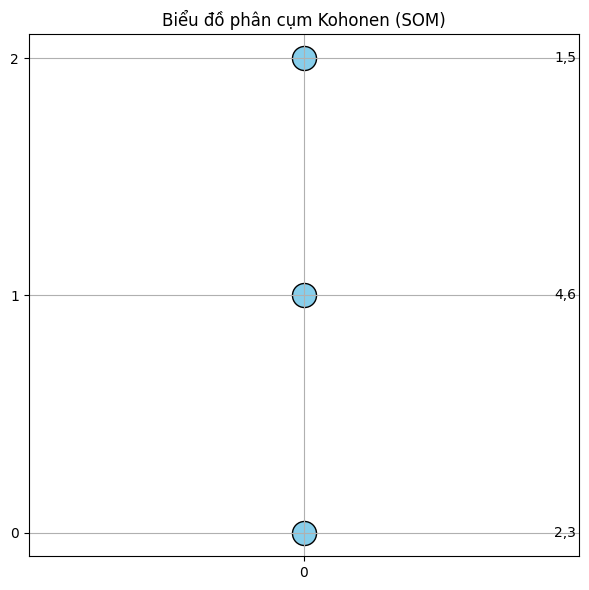

In [14]:
import matplotlib.pyplot as plt

def visualize_mapping(data, weights):
    grid_height, grid_width, _ = weights.shape
    mapping = {}  # neuron position => list of data indices

    for idx, sample in enumerate(data):
        bmu_idx = get_bmu(sample, weights)
        if bmu_idx in mapping:
            mapping[bmu_idx].append(idx + 1)  # đánh số bệnh nhân từ 1
        else:
            mapping[bmu_idx] = [idx + 1]

    # Vẽ biểu đồ
    plt.figure(figsize=(6, 6))
    for i in range(grid_height):
        for j in range(grid_width):
            pos = (i, j)
            y = grid_height - i - 1  # Lật trục y để vẽ từ trên xuống

            if pos in mapping:
                # Vẽ hình tròn tại nơ-ron
                plt.scatter(j, y, s=300, c='skyblue', edgecolors='black')
                
                # Chuỗi nhãn bệnh nhân cách nhau bằng dấu ,
                text = ','.join(str(x) for x in mapping[pos])
                
                # Ghi nhãn lệch ra bên ngoài hình tròn (bên phải)
                plt.text(j + 0.05, y, text, fontsize=10, ha='left', va='center', color='black')
            else:
                # Vẽ nơ-ron rỗng
                plt.scatter(j, y, s=300, c='white', edgecolors='black')

    plt.title("Biểu đồ phân cụm Kohonen (SOM)")
    plt.xticks(range(grid_width))
    plt.yticks(range(grid_height))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

data_array = df_3.to_numpy()
visualize_mapping(data_array, final_weights)